In [16]:
## Import Library
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

## Plate dimensions in Meters
X=1
Y=1
## Simulations Parameters
#mesh size 
del_x=0.01
del_y=0.01
h=0.01
#material properties
E=3e+4
nu=0.3
G=E/((1-nu)*2)
Rho=11000
#speed of wave in medium
ws=(G/Rho)**0.5
# Simulation time in S
c=0.15
delt= round(c*h/ws,4) 
print(delt)
tot_time=5
rx= round(((c*delt)/del_x)**2,6) 
ry= round(((c*delt)/del_y)**2,6)
print(rx)    
print(ry)

0.0011
0.000272
0.000272


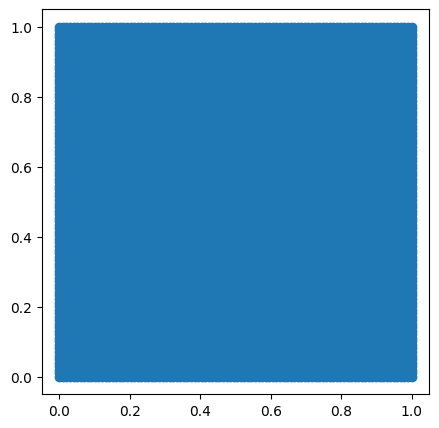

In [17]:
## Plate with Zero Deformation
x=np.linspace(0,X,100)
y=np.linspace(0,Y,100)
a,b=np.meshgrid(x,y)
plt.figure(figsize=(5,5))
plt.scatter(a,b)
plt.show()

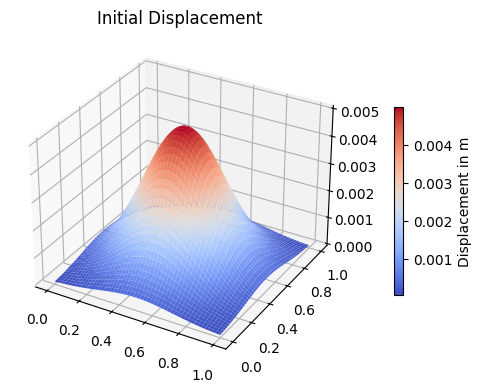

In [18]:
## Initial Condition
Z=(np.exp(-((a-0.5)**2 + (b-0.5)**2)/0.1))/200
Z_previ=Z
Z_crnt=Z_previ
Z_next=np.zeros([100,100])
Z_displacement=[]
## Plot Initial Condition
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111, projection="3d")
surf=ax.plot_surface(a,b,Z,cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)

plt.title("Initial Displacement")
plt.tight_layout()
plt.show()

In [20]:
## Solve the Equation with Central Difference Method
for t in range(0,int(tot_time/delt)):
    for i in range(1,99):
        for j in range(1,99):
            Z_disp= 2*Z_crnt[i,j] - Z_previ[i,j] + (rx)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
            Z_next[i][j]=Z_disp
    Z_previ= Z_crnt.copy()
    Z_crnt=Z_next.copy()
    Z_displacement.append(Z_crnt)

/var/folders/br/fy_nl9d92znbdsxrh0253n0w0000gn/T/ipykernel_2538/1756433660.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 500x500 with 2 Axes> than <Figure size 500x500 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)


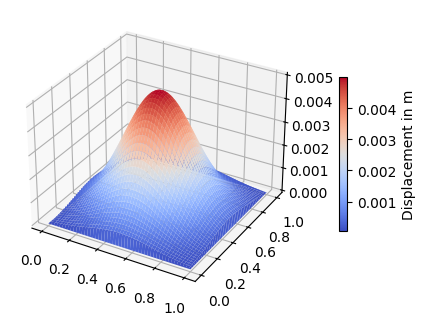

In [15]:
## Create Animation:
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(a,b,Z_displacement[0], cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)
ax.set_title("Vibration of Plate")

def animate(i):
    ax.clear()
    ax.plot_surface(a,b,Z_displacement[i], cmap="coolwarm")

anim=animation.FuncAnimation(fig,animate,frames=range(0,int(tot_time/delt),5))
writer=animation.FFMpegWriter(fps=(30))
anim.save("Vibration_of_Plate.mp4",writer=writer)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

## Plate dimensions in Meters
X=Y=1
del_x=del_y=0.01
h=0.01
E=3e4; nu=0.3; G=E/((1-nu)*2); Rho=11000
ws=(G/Rho)**0.5
c=0.2  # REDUCED for stability!
delt=round(c*h/ws,4)  # More precision
tot_time=2  # Reduced time
rx=((c*delt)/del_x)**2   
ry=((c*delt)/del_y)**2 
print(f'delt={delt}, rx={rx:.4f}, ry={ry:.4f}')  # Should be <0.25

## Mesh
x=np.linspace(0,X,100); y=np.linspace(0,Y,100)
a,b=np.meshgrid(x,y)

## Initial Condition
Z=(np.exp(-((a-0.5)**2 + (b-0.5)**2)/0.1))/200
Z_previ=Z.copy(); Z_crnt=Z.copy()
Z_displacement=[Z.copy()]

## FIXED SOLVER
for t in range(int(tot_time/delt)):
    Z_next=np.zeros([100,100])  # FIXED #1: Reset every iteration!
    
    for i in range(1,99):
        for j in range(1,99):
            # FIXED #2: Corrected stencil (your original had 2* terms wrong)
            Z_disp=2*Z_crnt[i,j] - Z_previ[i,j] + \
                   rx*(Z_crnt[i+1,j] + Z_crnt[i-1,j] - 2*Z_crnt[i,j]) + \
                   ry*(Z_crnt[i,j+1] + Z_crnt[i,j-1] - 2*Z_crnt[i,j])
            Z_next[i,j]=Z_disp
    
    # FIXED #3: Proper update order
    Z_displacement.append(Z_crnt.copy())  # Store BEFORE update
    Z_previ=Z_crnt.copy()
    Z_crnt=Z_next.copy()

Z_displacement=np.array(Z_displacement)

## FIXED Animation (No FFmpeg needed)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
zmin,zmax=Z_displacement.min(),Z_displacement.max()

def animate(i):
    ax.clear()
    ax.plot_surface(a,b,Z_displacement[i],cmap="coolwarm")
    ax.set_zlim(zmin,zmax)
    ax.set_title(f"t={i*delt:.3f}s")

anim=animation.FuncAnimation(fig,animate,frames=range(0,len(Z_displacement),3),interval=100)
anim.save("Vibration_of_Plate.mp4", writer=animation.FFMpegWriter(fps=15))
plt.show()